In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV

In [2]:
DATA_DIR = "../data/processed/"
df = pd.read_parquet(DATA_DIR + "processed_data.parquet")

In [15]:
print(df.shape)

(581012, 69)


Standarize data

In [3]:
X = df.drop('Cover_Type', axis=1).select_dtypes(include=[np.number])
y = df['Cover_Type']
inf_cols = X.columns[np.isinf(X).any()]
print("Columnas con valores infinitos:")
print(X[inf_cols].apply(lambda x: np.isinf(x).sum()))

Columnas con valores infinitos:
Distance_To_Hydrology_To_Roadways_Ratio    116
dtype: int64


In [4]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature Selection

In this section we will carry out the feature selection. We will follow different techniques such as, Variance Threshold, Recursive Feature Elimination, Lasso Regularization and Forward Selection. It is important to mention that regarding the dataset used, we will not be performing these stage of the process with any of the balance datasets. We are using the preprocessed dataset without imbalance mitigation. 

## PCA



In [13]:
pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

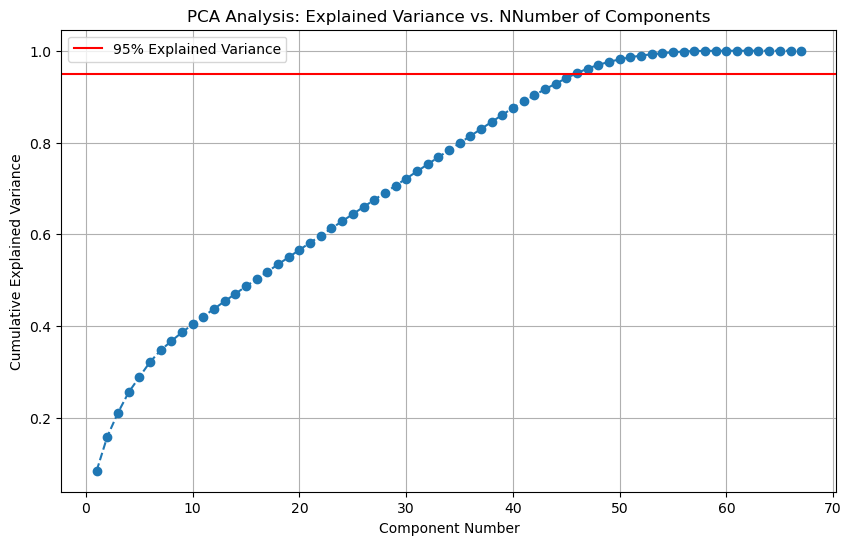

Number of components for 95% explained variance: 46


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Component Number')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Analysis: Explained Variance vs. NNumber of Components')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components for 95% explained variance: {n_components_95}")

As we can see above, 46 components are needed to explain a 95% of variance. Originally, the dataset is formed by 69 features. This suggest that the dataset has an intrinsic high dimensionality and variables don't show high correlation among them.

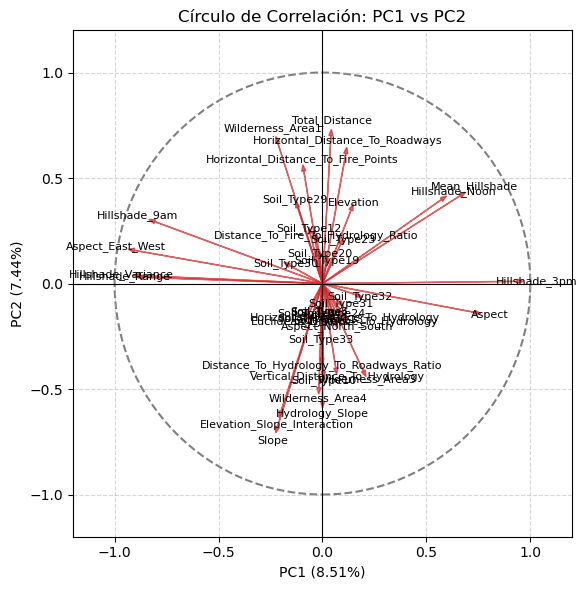

In [ ]:
def plot_correlation_circle(pca, features, pc_x=0, pc_y=1, threshold=0.1):
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    xs = loadings[:, pc_x]
    ys = loadings[:, pc_y]
    
    plt.figure(figsize=(6, 6))
    
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', linewidth=1.5)
    plt.gca().add_artist(circle)
    
    for i, feature in enumerate(features):
        magnitude = np.sqrt(xs[i]**2 + ys[i]**2)
        if magnitude > threshold:
            plt.arrow(0, 0, xs[i], ys[i], color='tab:red', head_width=0.02, alpha=0.7)
            plt.text(xs[i]*1.1, ys[i]*1.1, feature, color='black', ha='center', va='center', fontsize=8)
            
    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]*100:.2f}%)")
    plt.ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]*100:.2f}%)")
    plt.title(f"Círculo de Correlación: PC{pc_x+1} vs PC{pc_y+1}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()

# Llamar a la función
plot_correlation_circle(pca, X.columns)

## Variance Threshold

This technique simply consists of looking at the variance of the different features of the dataset. If the variance of a feature is close to zero, it means that it doesn't provide much information. This approach is computationally very cheap and it can reduce the dimensionality without any risk of overfitting, since it doesn't use the target.

In [43]:
p = 0.001 
th_val = p * (1 - p)

print(f"Calculated Variance Threshold: {th_val:.5f}")

sel = VarianceThreshold(threshold=th_val)

sel.fit(X)

irrelevant_cols = X.columns[~sel.get_support()]

print(f"Variables removed ({len(irrelevant_cols)}):")
print(list(irrelevant_cols))

X_var_filtered = X.loc[:, sel.get_support()]
X_var_filtered.head()

Calculated Variance Threshold: 0.00100
Variables removed (8):
['Soil_Type7', 'Soil_Type8', 'Soil_Type15', 'Soil_Type25', 'Soil_Type36', 'Soil_Type37', 'Wilderness_Count', 'Soil_Count']


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Hydrology_Slope,Mean_Hillshade,Hillshade_Variance,Hillshade_Range,Aspect_North_South,Aspect_East_West,Elevation_Slope_Interaction,Aspect_Cardinal_N,Aspect_Cardinal_S,Aspect_Cardinal_W
0,2.154000e+12,51,1.862977,23.645139,0.000000,26.857980,3.655638e+08,1.047068e+10,387.391263,6279,...,0.000000,2.290959e+13,9.778476,4.404586,0.629320,0.777146,200.797804,False,False,False
1,2.135244e+12,56,1.385538,21.521940,-7.165069,23.928401,3.591812e+08,1.109242e+10,397.053167,6225,...,-1.613539,2.409929e+13,9.717831,4.404586,0.559193,0.829038,162.083513,False,False,False
2,2.882498e+12,139,3.816336,24.077878,41.818255,57.678987,4.564437e+08,1.174252e+10,346.055522,6121,...,13.584314,2.434332e+13,10.578523,4.602801,-0.754710,0.656059,371.565214,False,True,False
3,2.809362e+12,155,5.690038,22.932715,70.286707,57.005087,4.875117e+08,1.174252e+10,305.632477,6211,...,25.901057,2.221968e+13,11.039084,4.718454,-0.906308,0.422618,531.667215,False,True,False
4,2.150866e+12,45,1.385538,18.376489,-1.055051,23.954930,3.591812e+08,1.088206e+10,393.827545,6172,...,-0.372045,2.361735e+13,9.732404,4.404586,0.707107,0.707107,162.247977,False,False,False


## RFECV (Recursive Feature Elimination with Cross Validation)

In this par of the featrure elimination process we are following the RFECV approach. This is a Recursive Feature Elimination approach with Cross Validation, which is more robust than the plain RFE. This approach tries with different feature subsets and selects the one that maximizes the score.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_var_filtered, y, test_size=0.3, random_state=42, stratify=y
)

NameError: name 'X_var_filtered' is not defined

In [47]:
clf = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
rfecv = RFECV(
    estimator=clf,
    step=2, 
    cv=StratifiedKFold(3), 
    scoring='f1_weighted', 
    min_features_to_select=10,
    n_jobs=-1
)

We are using as the scoring function the f1_weighted because, as we have mentioned before, we will carry out this process with the unbalanced dataset.

In [48]:
print("Executing RFECV...")
rfecv.fit(X_train, y_train)

Executing RFECV...


RFECV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
      estimator=RandomForestClassifier(max_depth=8, n_estimators=50, n_jobs=-1,
                                       random_state=42),
      min_features_to_select=10, n_jobs=-1, scoring='f1_weighted', step=2)

In [49]:
print(f"Optimum number of features: {rfecv.n_features_}")
selected_features_rfecv = X_train.columns[rfecv.support_]
print("Selected Features:", list(selected_features_rfecv))

Optimum number of features: 20
Selected Features: ['Elevation', 'Horizontal_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_Noon', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type2', 'Soil_Type4', 'Soil_Type10', 'Soil_Type12', 'Soil_Type22', 'Soil_Type23', 'Soil_Type38', 'Soil_Type39', 'Euclidean_Distance_To_Hydrology', 'Distance_To_Hydrology_To_Roadways_Ratio', 'Total_Distance', 'Aspect_North_South']


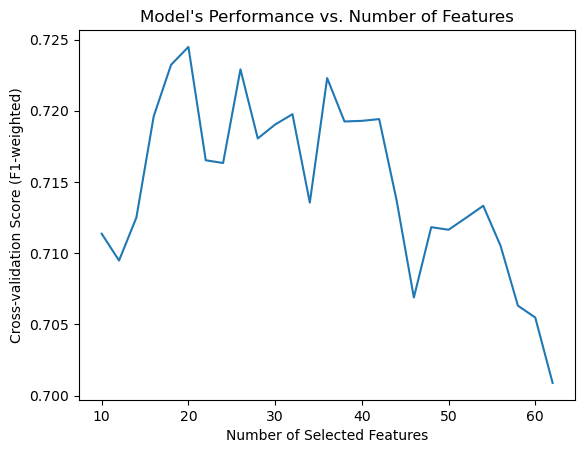

In [51]:
n_scores = len(rfecv.cv_results_["mean_test_score"])
plt.figure()
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-validation Score (F1-weighted)")
plt.plot(
    range(10, 10 + n_scores * 2, 2)[:n_scores],
    rfecv.cv_results_["mean_test_score"]
)
plt.title("Model's Performance vs. Number of Features")
plt.show()

We observe in the plot above, that the optimum number of features is 20. We see good performance also with 25 or 40 features, but the best score is achieved with the 20 features we have seen some cells above.

## Lasso Regularization

We will use a Logistic Regression with L1 penalty to perform feature selection. During the training, the model minimizes the loss as well as the magnitude of coefficients. This way, less important features obtain value 0 and thus, are removed and the model simplified. We will use Logistic Regression with Cross Validation to find the most optimal regularizer.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

In [8]:
print("Training Logistic Regression with L1 Penalty (Lasso)...")
lasso_lr = LogisticRegressionCV(
    solver='saga',           
    penalty='l1',            
    max_iter=5000,           
    cv=StratifiedKFold(3),                    
    scoring='f1_weighted',   
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lasso_lr.fit(X_scaled, y)

print(f"\nBest parameter C found: {lasso_lr.C_[0]:.6f}")
print(f"Lambda (1/C): {1/lasso_lr.C_[0]:.6f}")

# Extract feature importance
# For multi-class problems, we get the maximum magnitude of coefficients
coefs = np.max(np.abs(lasso_lr.coef_), axis=0)

Training Logistic Regression with L1 Penalty (Lasso)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 129 epochs took 160 seconds
convergence after 139 epochs took 171 seconds
convergence after 143 epochs took 173 seconds
convergence after 483 epochs took 553 seconds
convergence after 494 epochs took 555 seconds
convergence after 664 epochs took 758 seconds
convergence after 842 epochs took 940 seconds
convergence after 915 epochs took 1029 seconds
convergence after 1232 epochs took 1401 seconds
convergence after 1907 epochs took 2304 seconds
convergence after 693 epochs took 891 seconds
convergence after 114 epochs took 151 seconds
convergence after 16 epochs took 23 seconds
convergence after 2 epochs took 3 seconds
convergence after 2 epochs took 3 seconds
convergence after 2 epochs took 3 seconds
convergence after 2764 epochs took 3345 seconds
convergence after 3084 epochs took 3682 seconds
convergence after 807 epochs took 964 seconds
convergence after 117 epochs took 144 seconds
convergence after 18 epochs took 23 seconds
convergence after 2 epochs took 3 seconds

[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed: 122.6min finished



Best parameter C found: 0.000774
Lambda (1/C): 1291.549665


In [9]:
lasso_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient_Magnitude': coefs,
    'Is_Selected': coefs > 0 
})

lasso_importance = lasso_importance.sort_values(by='Coefficient_Magnitude', ascending=False)

selected_features_lasso = lasso_importance[lasso_importance['Is_Selected']]['Feature'].tolist()

print(f"\n{'='*60}")
print(f"Number of features selected by Lasso: {len(selected_features_lasso)}")
print(f"Number of features removed: {len(X.columns) - len(selected_features_lasso)}")
print(f"{'='*60}")

print("\nTop 15 features by Lasso importance:")
print(lasso_importance.head(15).to_string(index=False))


Number of features selected by Lasso: 59
Number of features removed: 8

Top 15 features by Lasso importance:
                           Feature  Coefficient_Magnitude  Is_Selected
                         Elevation               3.938861         True
                  Wilderness_Area4               0.945635         True
   Euclidean_Distance_To_Hydrology               0.465298         True
                  Wilderness_Area3               0.426996         True
                  Wilderness_Area1               0.417420         True
Horizontal_Distance_To_Fire_Points               0.357361         True
                       Soil_Type30               0.356004         True
                       Soil_Type39               0.341694         True
                       Soil_Type38               0.334865         True
                        Soil_Type4               0.307215         True
                        Soil_Type3               0.304463         True
                       Soil_Type10    